### 1. Data Loading & Initialization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import pickle
import re

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline
import shap

warnings.filterwarnings('ignore')

df = pd.read_csv('train.csv')
print(f"Dataset Shape: {df.shape}")

c:\Users\mohsi\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset Shape: (140700, 20)


### 2. Exploratory Data Analysis (EDA)

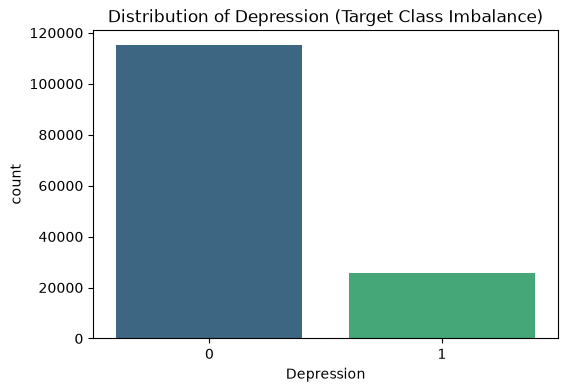

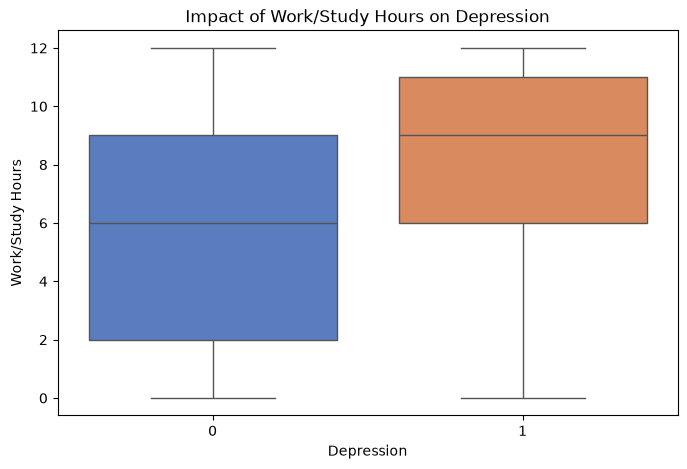

In [2]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Depression', data=df, palette='viridis')
plt.title("Distribution of Depression (Target Class Imbalance)")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='Depression', y='Work/Study Hours', data=df, palette='muted')
plt.title("Impact of Work/Study Hours on Depression")
plt.show()

### 3. Data Cleaning & Feature Engineering

In [3]:
# 1. Drop Noise & Target Leakage
cols_to_drop = ['id', 'Name', 'City', 'Have you ever had suicidal thoughts ?', 'CGPA']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# 2. Merge Mutually Exclusive Columns
df['Daily_Pressure'] = df['Academic Pressure'].fillna(df['Work Pressure'])
df['Daily_Satisfaction'] = df['Study Satisfaction'].fillna(df['Job Satisfaction'])
df.drop(columns=['Academic Pressure', 'Work Pressure', 'Study Satisfaction', 'Job Satisfaction'], inplace=True, errors='ignore')

# 3. Whitelist Filter for Corrupted Categorical Entries
valid_sleep = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours']
valid_diet = ['Healthy', 'Moderate', 'Unhealthy']
df.loc[~df['Sleep Duration'].isin(valid_sleep), 'Sleep Duration'] = np.nan
df.loc[~df['Dietary Habits'].isin(valid_diet), 'Dietary Habits'] = np.nan

# 4. Degree Standardization (normalized token matching, not raw regex word-boundaries)
grad_set = {'MS','MSC','MBA','MA','MPHIL','MD','MASTER','MASTERS','MTECH','MCA','MCOM','MED','MPHARM','MHM','ME','LLM','MPA','MARCH'}
undergrad_set = {'B','BSC','BA','BBA','BTECH','BE','BACHELOR','BACHELORS','UNDERGRAD','BCA','BCOM','BED','BPHARM','BHM','LLB','BARCH','BH'}
postgrad_set = {'PHD','POSTDOC'}
highersec_set = {'12','FSC','FA','ICS','ALEVEL','INTERMEDIATE','HIGHERSECONDARY'}
secondary_set = {'10','MATRIC','OLEVEL','SECONDARY','SSC'}
middle_set = {'6','7','8','MIDDLE'}
primary_set = {'1','2','3','4','5','PRIMARY'}

def categorize_degree(degree):
    val = str(degree).upper().strip()
    val_clean = re.sub(r'[^A-Z0-9]', '', val)
    if val_clean in postgrad_set: return 'Postgraduate'
    if val_clean in grad_set: return 'Graduate'
    if val_clean in undergrad_set: return 'Undergraduate'
    if 'CLASS12' in val_clean or val_clean in highersec_set: return 'Higher Secondary'
    if 'CLASS10' in val_clean or val_clean in secondary_set: return 'Secondary'
    if val_clean in middle_set: return 'Middle'
    if val_clean in primary_set: return 'Primary'
    return 'Others'

df['Degree'] = df['Degree'].apply(categorize_degree)

# 5. Clean Profession Column
df.loc[df['Working Professional or Student'] == 'Student', 'Profession'] = 'Not Applicable'
top_professions = df['Profession'].value_counts().head(15).index.tolist()
if 'Not Applicable' not in top_professions:
    top_professions.append('Not Applicable')
df['Profession'] = df['Profession'].apply(lambda x: x if x in top_professions else 'Others')

### 4. Anti-Leakage Split & Encoding

In [4]:
# --- Smart Encoding & Splitting ---

# 1. Manual Ordinal Mapping (Preserves Logic)
sleep_map = {'Less than 5 hours': 0, '5-6 hours': 1, '7-8 hours': 2, 'More than 8 hours': 3}
diet_map = {'Unhealthy': 0, 'Moderate': 1, 'Healthy': 2}
df['Sleep Duration'] = df['Sleep Duration'].map(sleep_map)
df['Dietary Habits'] = df['Dietary Habits'].map(diet_map)

# 2. Label Encoding for Nominal Variables
nominal_cols = ['Gender', 'Working Professional or Student', 'Profession', 'Degree', 'Family History of Mental Illness']
encoders = {}
for col in nominal_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# 3. SPLIT FIRST (Zero Data Leakage)
X = df.drop(columns=['Depression'])
y = df['Depression']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. IMPUTE AFTER SPLITTING
num_cols = ['Age', 'Work/Study Hours', 'Financial Stress', 'Daily_Pressure', 'Daily_Satisfaction', 'Sleep Duration', 'Dietary Habits']

train_medians = X_train[num_cols].median()
train_modes = X_train[nominal_cols].mode().iloc[0]

X_train[num_cols] = X_train[num_cols].fillna(train_medians)
X_train[nominal_cols] = X_train[nominal_cols].fillna(train_modes)

X_test[num_cols] = X_test[num_cols].fillna(train_medians)
X_test[nominal_cols] = X_test[nominal_cols].fillna(train_modes)

### 5. Isolated 5-Fold Stratified Cross-Validation (Model Selection)

In [5]:
# --- Isolated CV Pipeline ---
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Naive Bayes": GaussianNB(),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Decision Tree": DecisionTreeClassifier(max_depth=7, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=7, random_state=42),
    "Linear SVM": make_pipeline(StandardScaler(), LinearSVC(dual=False, random_state=42)),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
}

results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Running Isolated 5-Fold Cross-Validation. Please wait...\n")

for name, pipeline in models.items():
    start_time = time.time()
    cv_results = cross_validate(pipeline, X_train, y_train, cv=skf, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

    results.append([
        name, cv_results['test_accuracy'].mean(), cv_results['test_f1'].mean(),
        cv_results['test_roc_auc'].mean(), time.time() - start_time
    ])

results_df = pd.DataFrame(results, columns=['Model', 'CV Mean Accuracy', 'CV Mean F1-Score', 'CV Mean ROC-AUC', 'Time (s)'])
results_df.sort_values(by='CV Mean ROC-AUC', ascending=False, inplace=True)
display(results_df)

Running Isolated 5-Fold Cross-Validation. Please wait...



,Model,CV Mean Accuracy,CV Mean F1-Score,CV Mean ROC-AUC,Time (s)
6,XGBoost,0.923969,0.787055,0.963636,5.031598
0,Logistic Regression,0.920824,0.774814,0.961031,10.798384
5,Linear SVM,0.921215,0.776842,0.960940,1.218515
4,Random Forest,0.919234,0.766810,0.957547,12.504888
3,Decision Tree,0.910919,0.748300,0.950602,1.285343
1,Naive Bayes,0.878420,0.712045,0.933674,0.762537
2,KNN,0.910812,0.746857,0.923886,91.216468


### 6. Final XGBoost Training, Evaluation & SHAP Export

Training Final Production XGBoost Model...

--- Final Model Evaluation (Test Set) ---
Final ROC-AUC Score: 0.9627

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93     23027
           1       0.65      0.91      0.76      5113

    accuracy                           0.89     28140
   macro avg       0.81      0.90      0.84     28140
weighted avg       0.92      0.89      0.90     28140



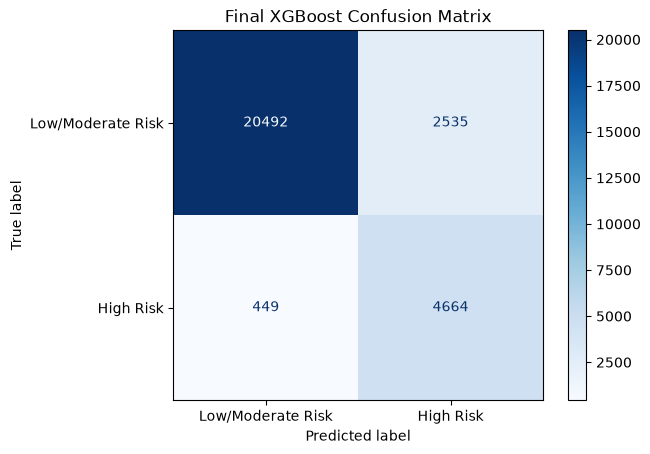


Generating SHAP Explainer and saving assets...
Assets saved successfully. The pipeline is ready for app.py!


In [6]:
# --- Final XGBoost Model ---
print("Training Final Production XGBoost Model...")
pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

final_model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=pos_weight,
    min_child_weight=20,   # Prevents overfitting on rare/OOD demographics
    colsample_bytree=0.7,  # Adds randomness across habit features per tree
    subsample=0.8,
    random_state=42
)
final_model.fit(X_train, y_train)

print("\n--- Final Model Evaluation (Test Set) ---")
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

print(f"Final ROC-AUC Score: {roc_auc_score(y_test, y_prob_final):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low/Moderate Risk', 'High Risk'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Final XGBoost Confusion Matrix")
plt.show()

print("\nGenerating SHAP Explainer and saving assets...")
explainer = shap.TreeExplainer(final_model)

with open('mindpulse_model.pkl', 'wb') as f: pickle.dump(final_model, f)
with open('mindpulse_explainer.pkl', 'wb') as f: pickle.dump(explainer, f)
with open('mindpulse_encoders.pkl', 'wb') as f: pickle.dump(encoders, f)
print("Assets saved successfully. The pipeline is ready for app.py!")